In [1]:
# python
import sys
import importlib
# columnar analysis
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea import processor
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import sidm_processor, utilities, scaleout, selection, llpnanoaodschema
#from sidm.tools import llpnanoaodschema_0726 as llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(sidm_processor)
importlib.reload(utilities)
importlib.reload(scaleout)
importlib.reload(selection)
importlib.reload(llpnanoaodschema)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
from hist import Hist

In [2]:
 samples = [
   "TTJets", 

]
fileset = utilities.make_fileset(samples, 
                                 "llpNanoAOD_v2", 
                                 location_cfg="backgrounds.yaml",
                                 # max_files =100
                                  max_files =1
                                )

runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    #executor=processor.DaskExecutor(client=client),
    #schema=NanoAODSchema,
    #schema=llpnanoaodschema.NanoAODSchema,
    schema=llpnanoaodschema.LLPNanoAODSchema,
    #maxchunks=1,
    skipbadfiles=True,
)

channels = [
    'baseNoTriggerNoLjNoLjsource',
#    '2dsa1muLjCC',
#    '2dsa1muLj0chargeCC',
#    '1muLjCC',
#    '1muLj2muCC',
#    '1muLj2dsaMuCC',
#    '1muLj0charge2muCC',
#    '1muLjCC0charge',
#    '1muLj2muCC0charge',
#    '1muLj2dsaMuCC0charge',
#    '1muLj0charge2muCC0charge',
    '2muCC0charge',
    'CC0charge',
    'justCC',
    '2muCC',
    '0chargeCC',
    '0chargeCC0charge',
]

p = sidm_processor.SidmProcessor(
    channels,
    ["base"],
    verbose=True,
)


out = {}
for i, sample in enumerate(samples):
    print(f"Processing {sample}")
    fileset_one_sample = {samples[i]:fileset.get(samples[i])}
    output = runner.run(fileset_one_sample, treename='Events', processor_instance=p)
    #Add this sample's output to the out variable
    out[sample] = output["out"][sample]



Output()

Processing TTJets


Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

...

Applying ljs pT > 30 GeV

Applying ljs mu_charge == 0

Applying cut: PV filter

Applying cut: pass triggers

TTJets is simulation. Scaling histograms or cutflows according to lumi*xs.


Text(0.5, 1.07, 'TTJets')

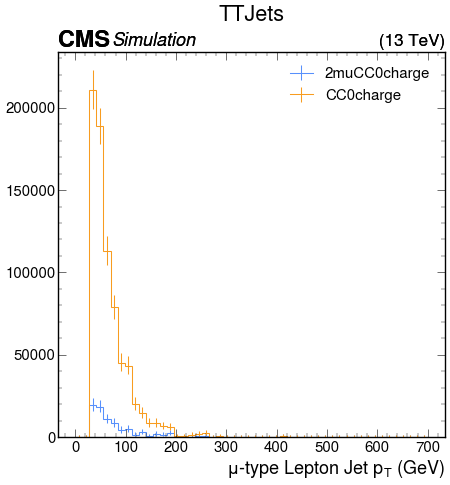

In [3]:
channel1 = 1
channel2 = 2
utilities.plot(out[samples[i]]["hists"]["mu_lj_pt"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[i]]["hists"]["mu_lj_pt"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[i],y=1.07)

Text(0.5, 1.07, 'TTJets')

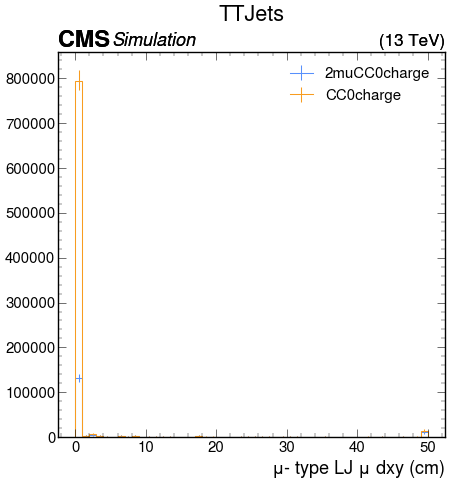

In [4]:
channel1 = 1
channel2 = 2
utilities.plot(out[samples[i]]["hists"]["mu_lj_muon_dxy"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[i]]["hists"]["mu_lj_muon_dxy"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[i],y=1.07)

Text(0.5, 1.07, 'TTJets')

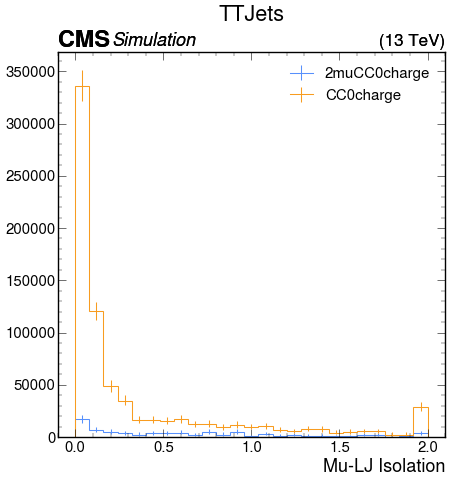

In [5]:
channel1 = 1
channel2 = 2
utilities.plot(out[samples[i]]["hists"]["mu_lj_isolation"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[i]]["hists"]["mu_lj_isolation"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[i],y=1.07)

Text(0.5, 1.07, 'TTJets')

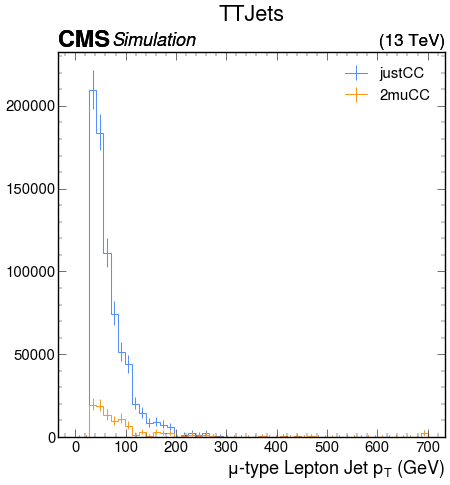

In [6]:
channel1 = 3
channel2 = 4
utilities.plot(out[samples[i]]["hists"]["mu_lj_pt"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[i]]["hists"]["mu_lj_pt"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[i],y=1.07)

Text(0.5, 1.07, 'TTJets')

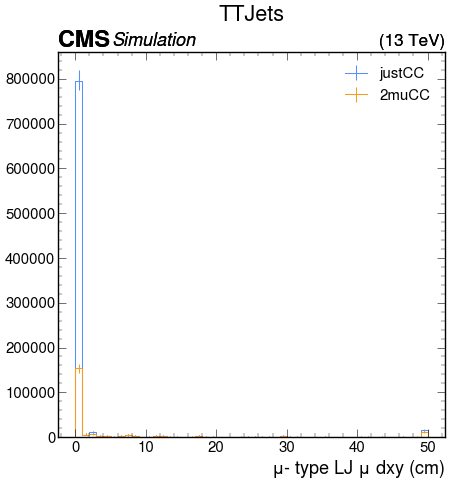

In [7]:
channel1 = 3
channel2 = 4
utilities.plot(out[samples[i]]["hists"]["mu_lj_muon_dxy"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[i]]["hists"]["mu_lj_muon_dxy"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[i],y=1.07)

Text(0.5, 1.07, 'TTJets')

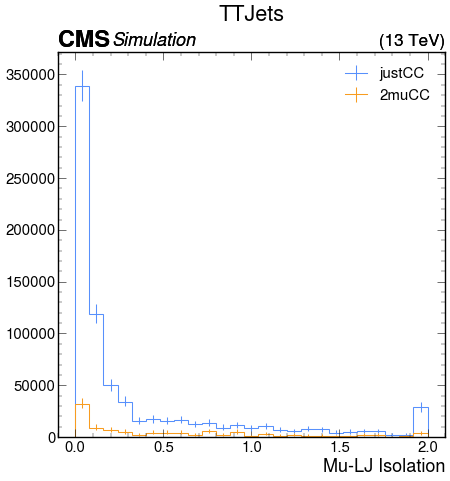

In [10]:
channel1 = 3
channel2 = 4
utilities.plot(out[samples[i]]["hists"]["mu_lj_isolation"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[i]]["hists"]["mu_lj_isolation"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[i],y=1.07)

Text(0.5, 1.07, 'TTJets')

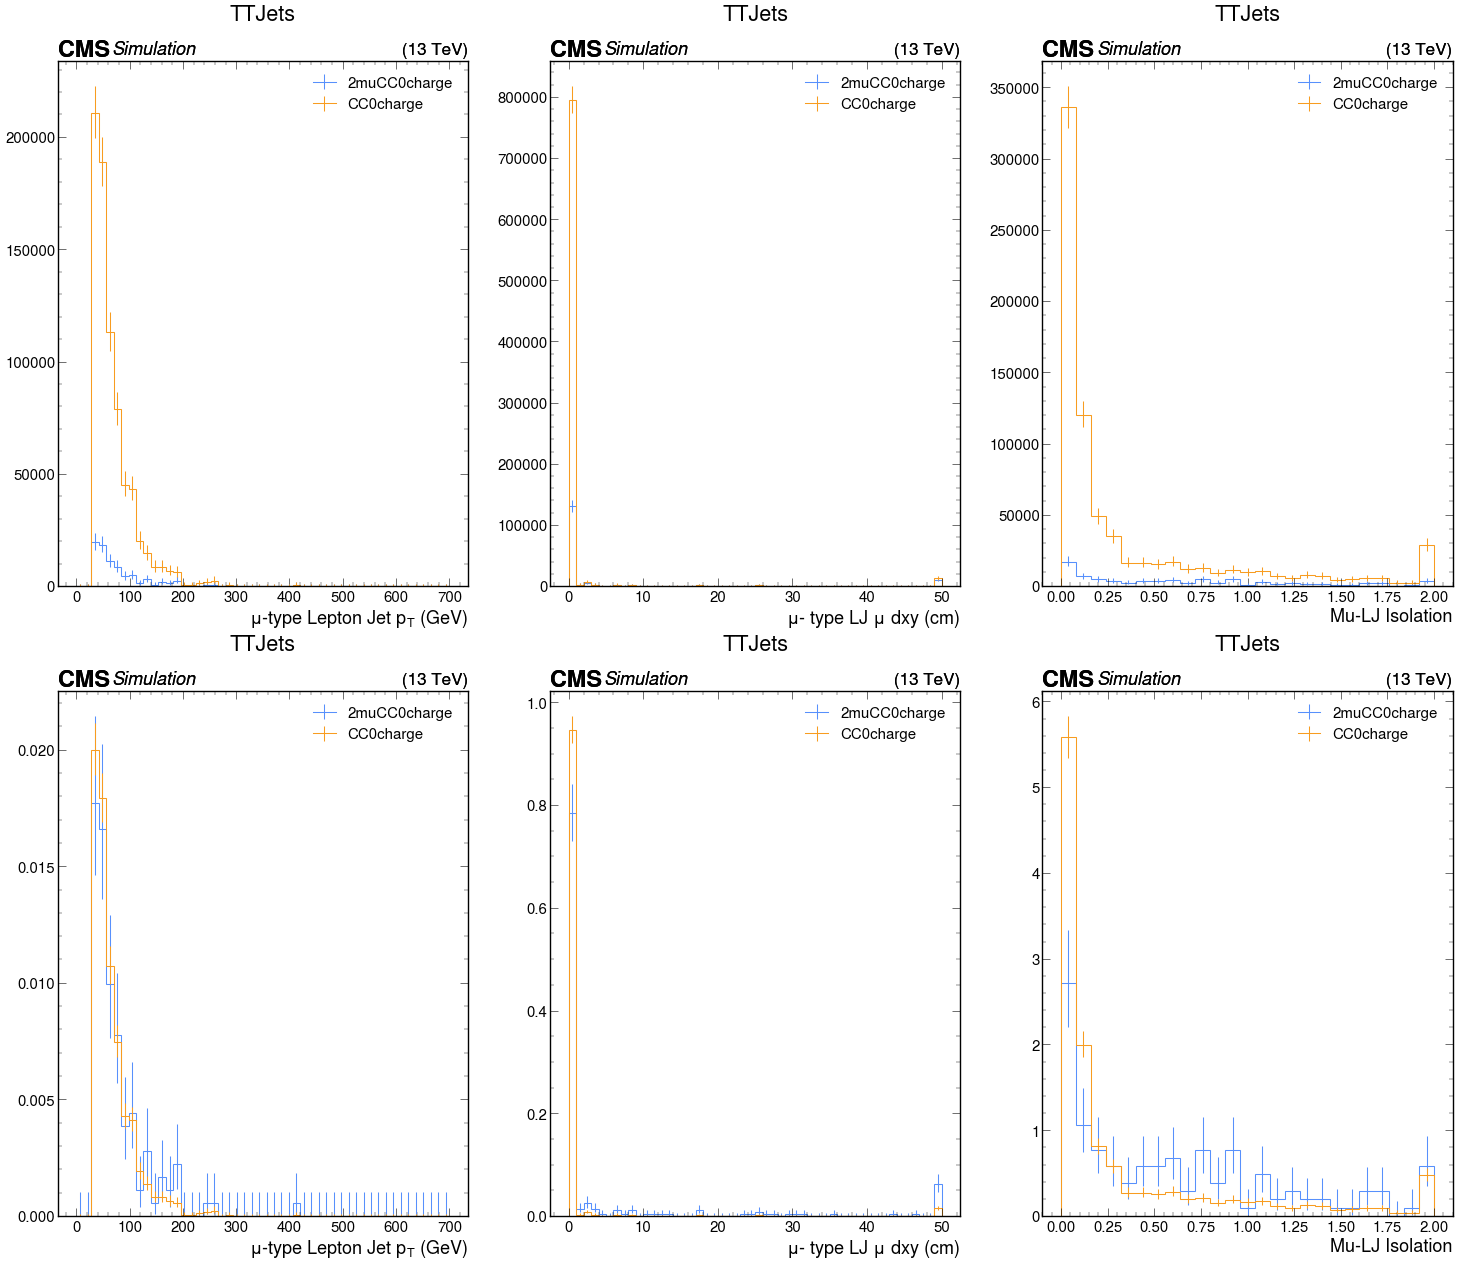

In [33]:
plt.subplots(2, 3, figsize=(36,30))
plt.subplot(2, 3, 1)
channel1 = 1
channel2 = 2
utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(2, 3, 2)
utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channels[channel2], ::2j],label=channels[channel2])
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(2, 3, 3)
utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)


plt.subplot(2, 3, 4)
utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channels[channel1], ::2j],label=channels[channel1],density=True)
utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channels[channel2], ::2j],label=channels[channel2],density=True)
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(2, 3, 5)
utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channels[channel1], ::2j],label=channels[channel1],density=True)
utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channels[channel2], ::2j],label=channels[channel2],density=True)
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(2, 3, 6)
utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channels[channel1], ::2j],label=channels[channel1],density=True)
utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channels[channel2], ::2j],label=channels[channel2],density=True)
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

Text(0.5, 1.07, 'TTJets')

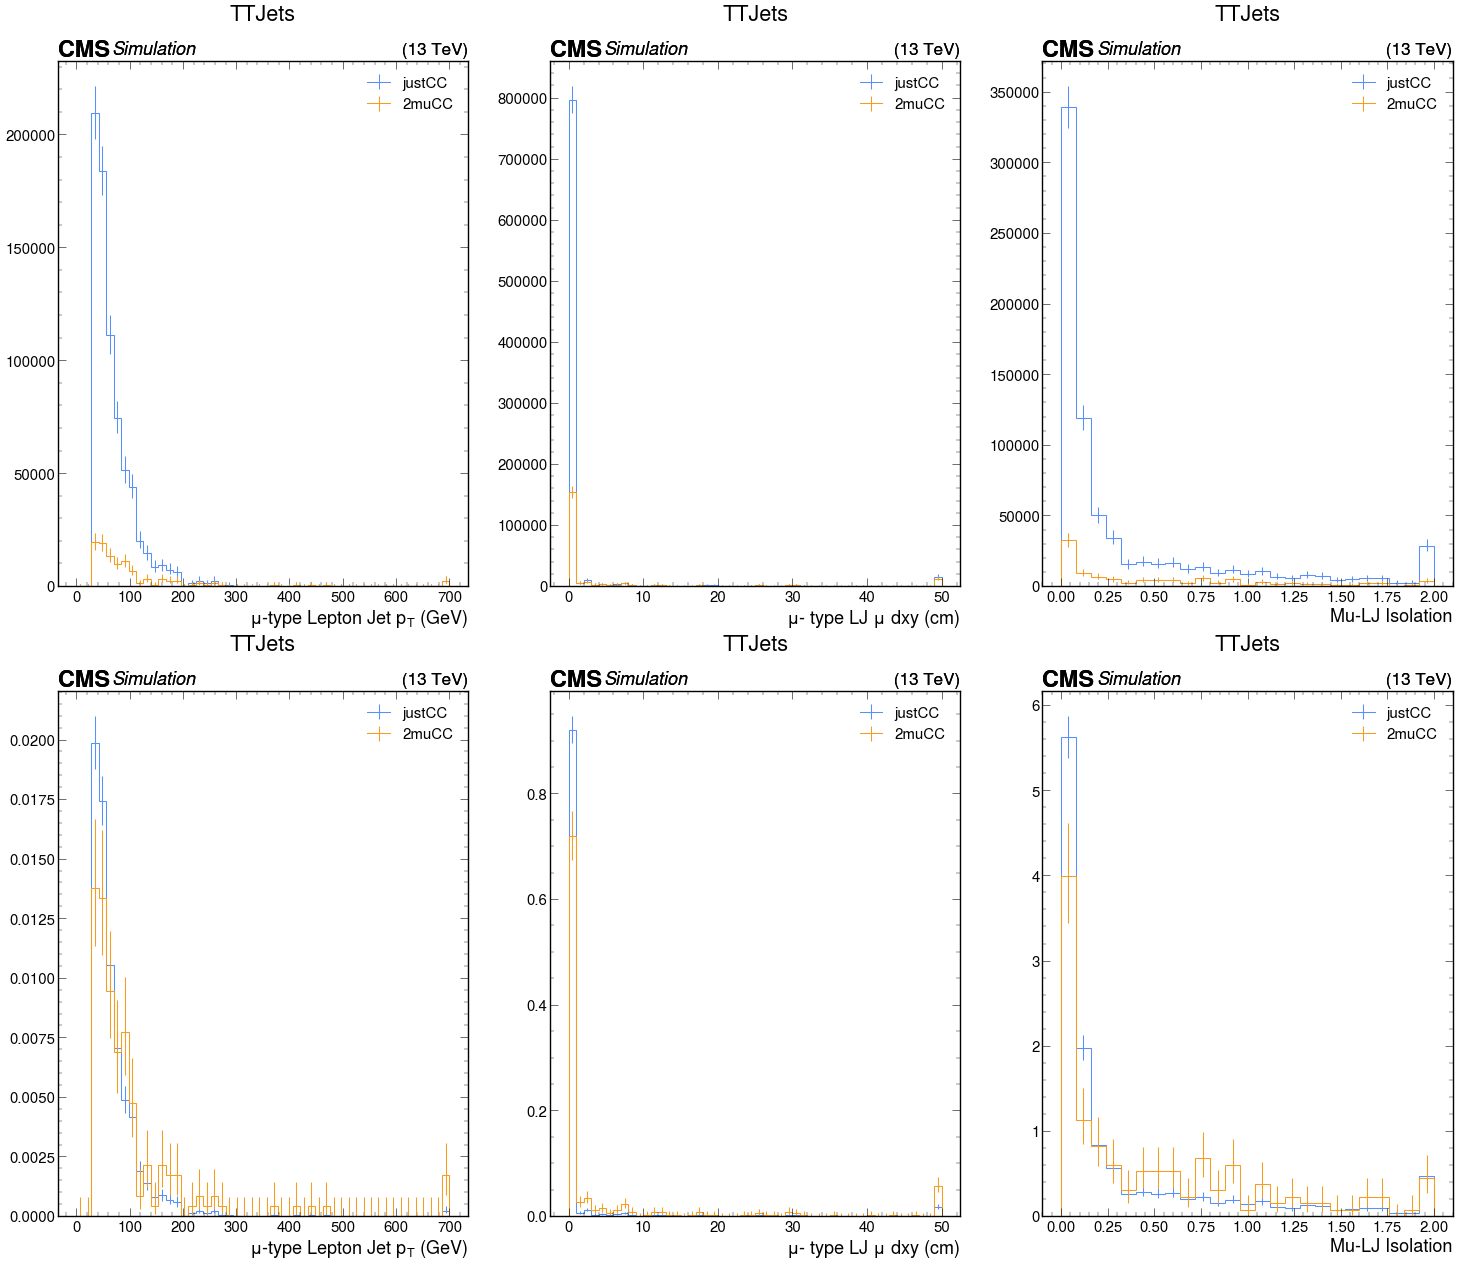

In [15]:
plt.subplots(2, 3, figsize=(36,30))
plt.subplot(2, 3, 1)
channel1 = 3
channel2 = 4
utilities.plot(out[samples[i]]["hists"]["mu_lj_pt"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[i]]["hists"]["mu_lj_pt"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[i],y=1.07)

plt.subplot(2, 3, 2)
utilities.plot(out[samples[i]]["hists"]["mu_lj_muon_dxy"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[i]]["hists"]["mu_lj_muon_dxy"][channels[channel2], ::2j],label=channels[channel2])
plt.legend()
plt.title(samples[i],y=1.07)

plt.subplot(2, 3, 3)
utilities.plot(out[samples[i]]["hists"]["mu_lj_isolation"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[i]]["hists"]["mu_lj_isolation"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[i],y=1.07)


plt.subplot(2, 3, 4)
utilities.plot(out[samples[i]]["hists"]["mu_lj_pt"][channels[channel1], ::2j],label=channels[channel1],density=True)
utilities.plot(out[samples[i]]["hists"]["mu_lj_pt"][channels[channel2], ::2j],label=channels[channel2],density=True)
#plt.yscale("log")
plt.legend()
plt.title(samples[i],y=1.07)

plt.subplot(2, 3, 5)
utilities.plot(out[samples[i]]["hists"]["mu_lj_muon_dxy"][channels[channel1], ::2j],label=channels[channel1],density=True)
utilities.plot(out[samples[i]]["hists"]["mu_lj_muon_dxy"][channels[channel2], ::2j],label=channels[channel2],density=True)
plt.legend()
plt.title(samples[i],y=1.07)

plt.subplot(2, 3, 6)
utilities.plot(out[samples[i]]["hists"]["mu_lj_isolation"][channels[channel1], ::2j],label=channels[channel1],density=True)
utilities.plot(out[samples[i]]["hists"]["mu_lj_isolation"][channels[channel2], ::2j],label=channels[channel2],density=True)
#plt.yscale("log")
plt.legend()
plt.title(samples[i],y=1.07)

Text(0.5, 1.07, 'TTJets')

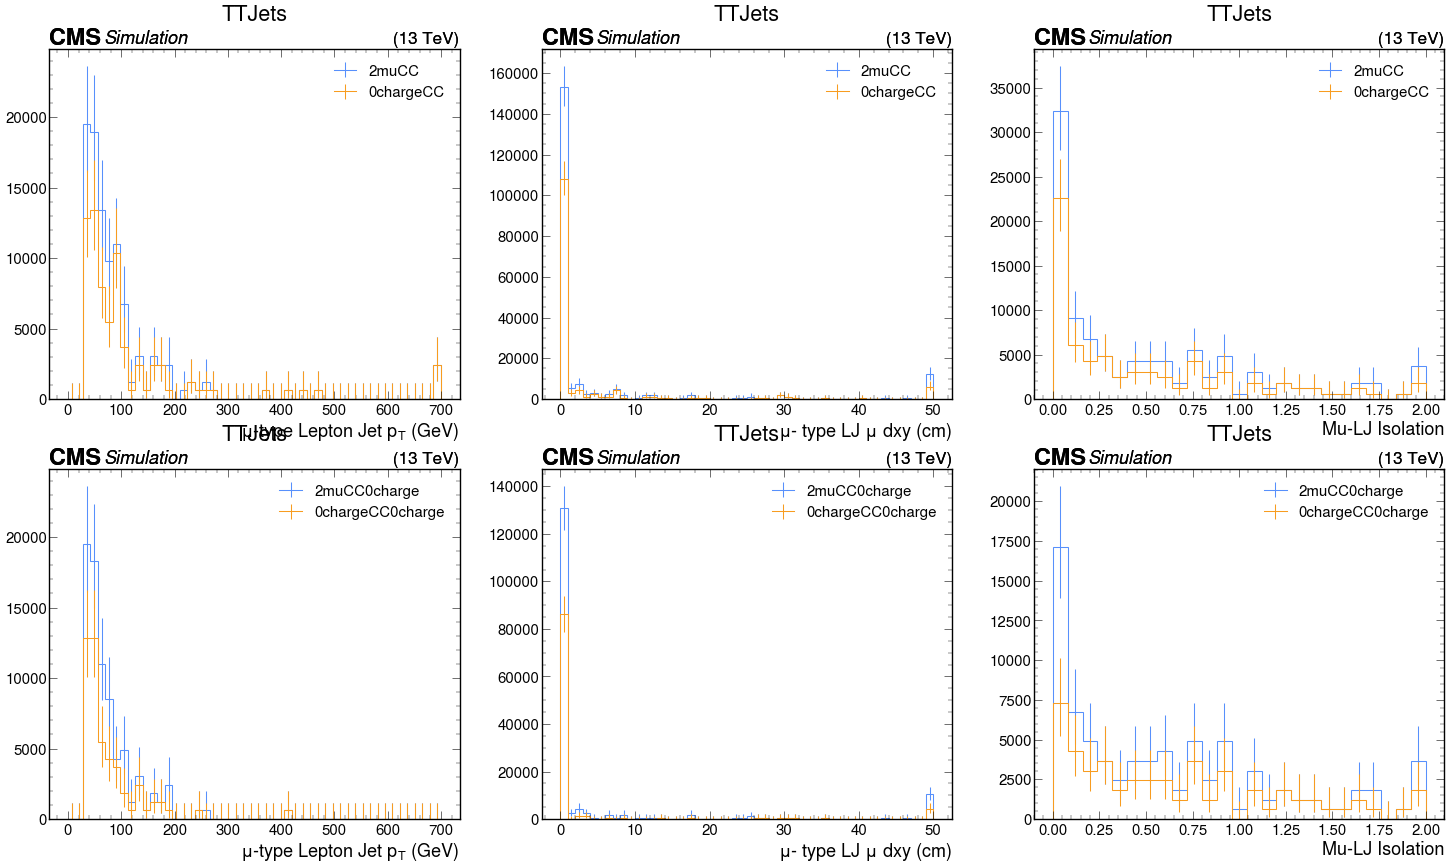

In [34]:
plt.subplots(2, 3, figsize=(36,20))
plt.subplot(2, 3, 1)
channel1 = 4
channel2 = 5
utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(2, 3, 2)
utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channels[channel2], ::2j],label=channels[channel2])
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(2, 3, 3)
utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)


channel1 = 1
channel2 = 6
plt.subplot(2, 3, 4)
utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(2, 3, 5)
utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channels[channel2], ::2j],label=channels[channel2])
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(2, 3, 6)
utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)


Text(0.5, 1.07, 'TTJets')

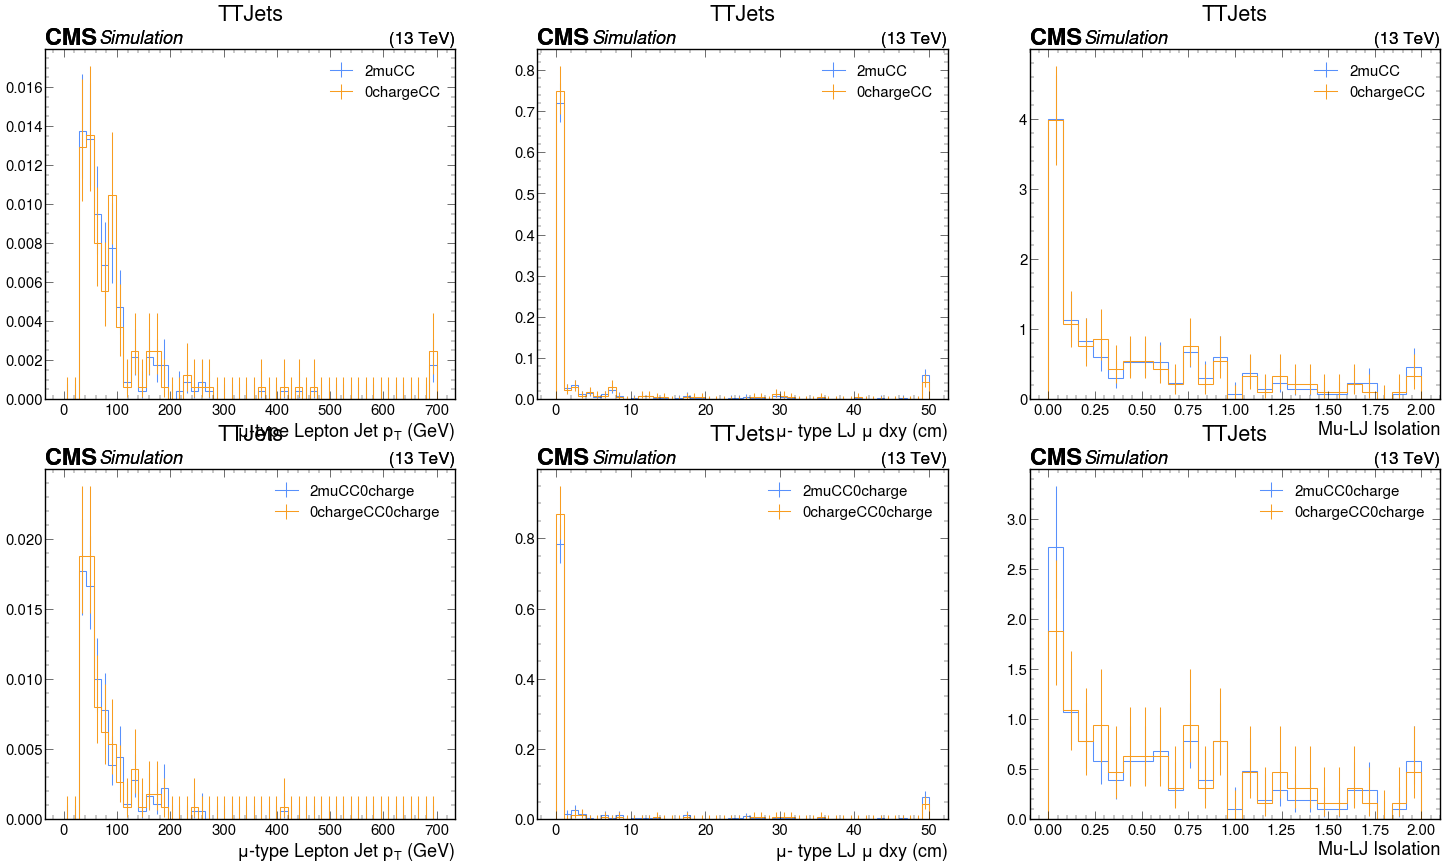

In [35]:
plt.subplots(2, 3, figsize=(36,20))
plt.subplot(2, 3, 1)
channel1 = 4
channel2 = 5
utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channels[channel1], ::2j],label=channels[channel1],density=True)
utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channels[channel2], ::2j],label=channels[channel2],density=True)
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(2, 3, 2)
utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channels[channel1], ::2j],label=channels[channel1],density=True)
utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channels[channel2], ::2j],label=channels[channel2],density=True)
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(2, 3, 3)
utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channels[channel1], ::2j],label=channels[channel1],density=True)
utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channels[channel2], ::2j],label=channels[channel2],density=True)
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

channel1 = 1
channel2 = 6
plt.subplot(2, 3, 4)
utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channels[channel1], ::2j],label=channels[channel1],density=True)
utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channels[channel2], ::2j],label=channels[channel2],density=True)
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(2, 3, 5)
utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channels[channel1], ::2j],label=channels[channel1],density=True)
utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channels[channel2], ::2j],label=channels[channel2],density=True)
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(2, 3, 6)
utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channels[channel1], ::2j],label=channels[channel1],density=True)
utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channels[channel2], ::2j],label=channels[channel2],density=True)
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

Text(0.5, 1.07, 'TTJets')

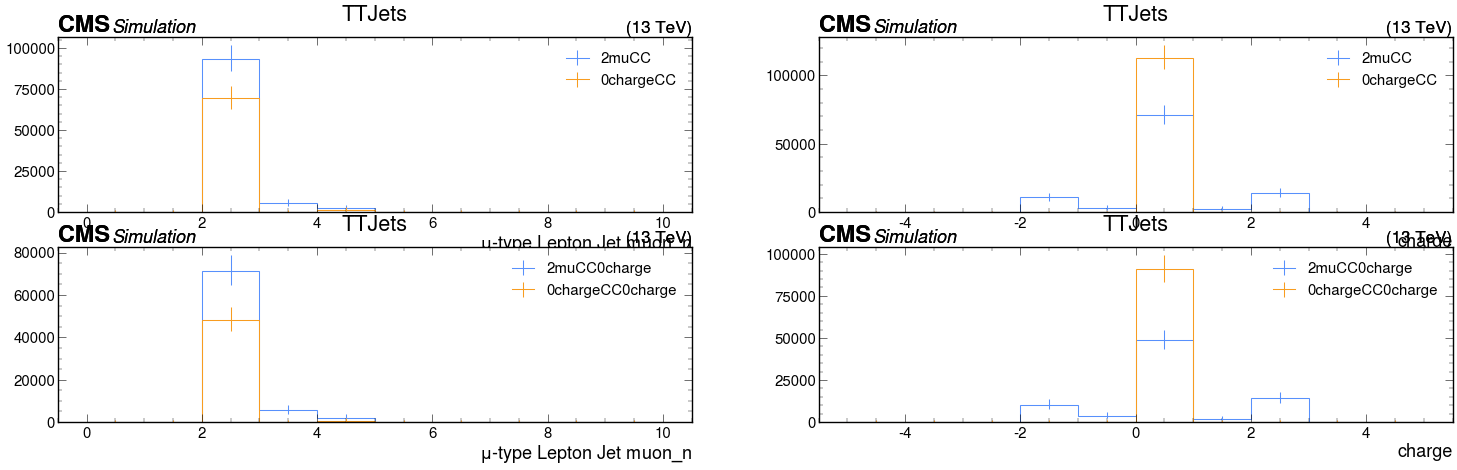

In [36]:
plt.subplots(2, 2, figsize=(36,10))
plt.subplot(2, 2, 1)
channel1 = 4
channel2 = 5
utilities.plot(out[samples[0]]["hists"]["mu_lj_muonN"][channels[channel1], ::],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_muonN"][channels[channel2], ::],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(2, 2, 2)
utilities.plot(out[samples[0]]["hists"]["mu_lj_charge"][channels[channel1], ::],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_charge"][channels[channel2], ::],label=channels[channel2])
plt.legend()
plt.title(samples[0],y=1.07)


channel1 = 1
channel2 = 6

plt.subplot(2, 2, 3)
utilities.plot(out[samples[0]]["hists"]["mu_lj_muonN"][channels[channel1], ::],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_muonN"][channels[channel2], ::],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(2, 2, 4)
utilities.plot(out[samples[0]]["hists"]["mu_lj_charge"][channels[channel1], ::],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_charge"][channels[channel2], ::],label=channels[channel2])
plt.legend()
plt.title(samples[0],y=1.07)



Text(0.5, 1.07, 'TTJets')

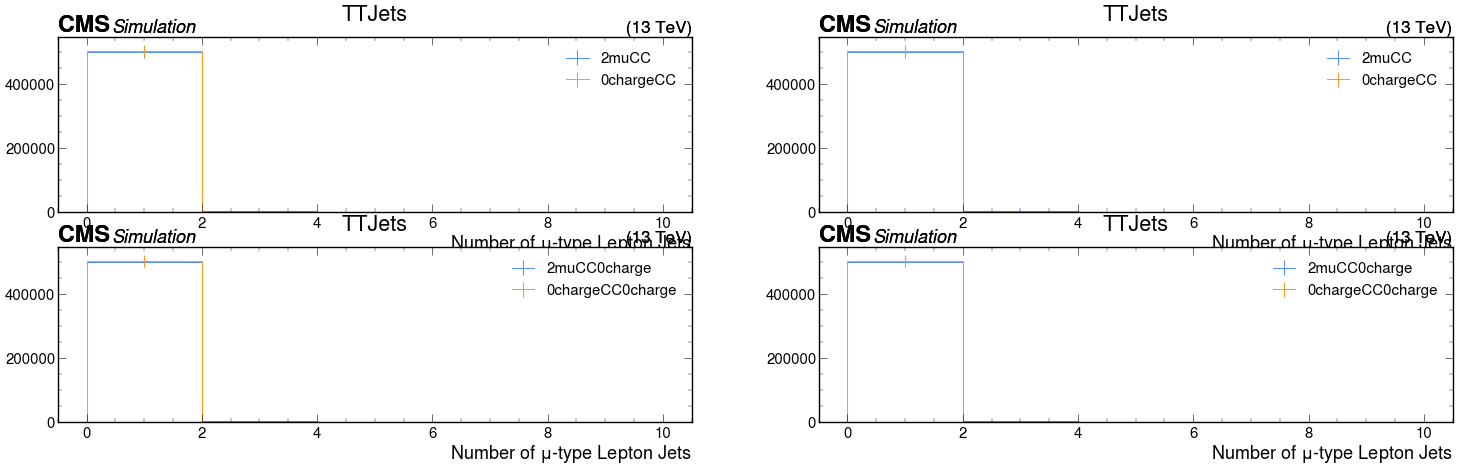

In [37]:
plt.subplots(2, 2, figsize=(36,10))
plt.subplot(2, 2, 1)
channel1 = 4
channel2 = 5
compare = "mu_lj_n"
utilities.plot(out[samples[0]]["hists"][compare][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"][compare][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(2, 2, 2)
utilities.plot(out[samples[0]]["hists"][compare][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"][compare][channels[channel2], ::2j],label=channels[channel2])
plt.legend()
plt.title(samples[0],y=1.07)


channel1 = 1
channel2 = 6

plt.subplot(2, 2, 3)
utilities.plot(out[samples[0]]["hists"][compare][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"][compare][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(2, 2, 4)
utilities.plot(out[samples[0]]["hists"][compare][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"][compare][channels[channel2], ::2j],label=channels[channel2])
plt.legend()
plt.title(samples[0],y=1.07)



In [14]:
channel1 = 4
channel2 = 1
compare = ['mu_lj_muonN','mu_lj_charge',"mu_lj_n","mu_lj_isolation","mu_lj_muon_dxy","mu_lj_pt"]

for i in compare:
    print(i)
    print(f'{channels[channel1]}: {out[samples[0]]["hists"][i].integrate('channel', '2muCC').sum}')
    print(f'{channels[channel2]}: {out[samples[0]]["hists"][i].integrate('channel', '2muCC0charge').sum}')
    print("")

mu_lj_muonN
2muCC: <bound method BaseHist.sum of Hist(Regular(10, 0, 10, name='mu_ljs_muon_n', label='$\\mu$-type Lepton Jet muon_n'), storage=Weight()) # Sum: WeightedSum(value=221079, variance=1.35017e+08)>
2muCC0charge: <bound method BaseHist.sum of Hist(Regular(10, 0, 10, name='mu_ljs_muon_n', label='$\\mu$-type Lepton Jet muon_n'), storage=Weight()) # Sum: WeightedSum(value=1.80589e+06, variance=1.10289e+09)>

mu_lj_charge
2muCC: <bound method BaseHist.sum of Hist(Regular(10, -5, 5, name='charge'), storage=Weight()) # Sum: WeightedSum(value=305358, variance=1.86487e+08)>
2muCC0charge: <bound method BaseHist.sum of Hist(Regular(10, -5, 5, name='charge'), storage=Weight()) # Sum: WeightedSum(value=1.97445e+06, variance=1.20583e+09)>

mu_lj_n
2muCC: <bound method BaseHist.sum of Hist(Regular(10, 0, 10, name='mu_ljs_n', label='Number of $\\mu$-type Lepton Jets'), storage=Weight()) # Sum: WeightedSum(value=1.51152e+06, variance=9.23112e+08)>
2muCC0charge: <bound method BaseHist.sum of 

In [12]:
channel1 = 4
channel2 = 1
compare = ['mu_lj_muonN','mu_lj_charge',"mu_lj_n","mu_lj_isolation","mu_lj_muon_dxy","mu_lj_pt"]

for i in compare:
    print(i)
    print(f'{channels[channel1]}: {out[samples[0]]["hists"][i][channel1, ::].values(flow=True).sum()}')
    print(f'{channels[channel2]}: {out[samples[0]]["hists"][i][channel2, ::].values(flow=True).sum()}')
    print("")

mu_lj_muonN
2muCC: 101378.9072265625
2muCC0charge: 78782.40380859375

mu_lj_charge
2muCC: 101378.9072265625
2muCC0charge: 78782.40380859375

mu_lj_n
2muCC: 503840.95458984375
2muCC0charge: 503840.95458984375

mu_lj_isolation
2muCC: 101378.9072265625
2muCC0charge: 78782.40380859375

mu_lj_muon_dxy
2muCC: 213139.99169921875
2muCC0charge: 166725.55224609375

mu_lj_pt
2muCC: 101378.9072265625
2muCC0charge: 78782.40380859375



In [31]:
print(out[samples[0]]["hists"]["mu_lj_isolation"][channels[3], ::].axes[0].traits)

Traits(underflow=True, overflow=True, circular=False, growth=False, continuous=True, ordered=True)


In [61]:
out[samples[0]]["cutflow"][channels[4]].print_table()
print()
out[samples[0]]["cutflow"][channels[1]].print_table()
print()

cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection           28221812.0   28221812.0
PV filter              28221812.0   28221812.0
pass triggers            503841.0     503841.0

cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection           28221812.0   28221812.0
PV filter              28221812.0   28221812.0
pass triggers            503841.0     503841.0



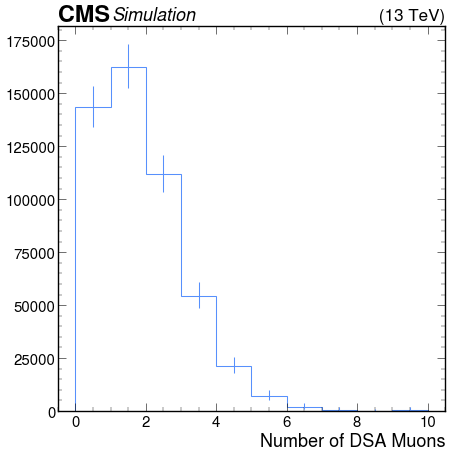

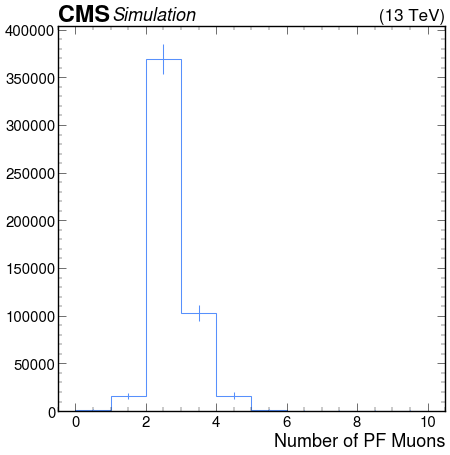

dsaMuon_n
justCC: 503841

muon_n
justCC: 503841



In [63]:
utilities.plot(out[samples[0]]["hists"]["dsaMuon_n"][channels[3], ::],label="DSA")
plt.show()
utilities.plot(out[samples[0]]["hists"]["muon_n"][channels[3], ::],label="PF")
plt.show()

channel1 = 3
compare = ["dsaMuon_n","muon_n"]

for i in compare:
    print(i)
    print(f'{channels[channel1]}: {out[samples[0]]["hists"][i][channels[channel1], ::].values().sum():.0f}')
    print("")

Text(0.5, 1.07, 'TTJets')

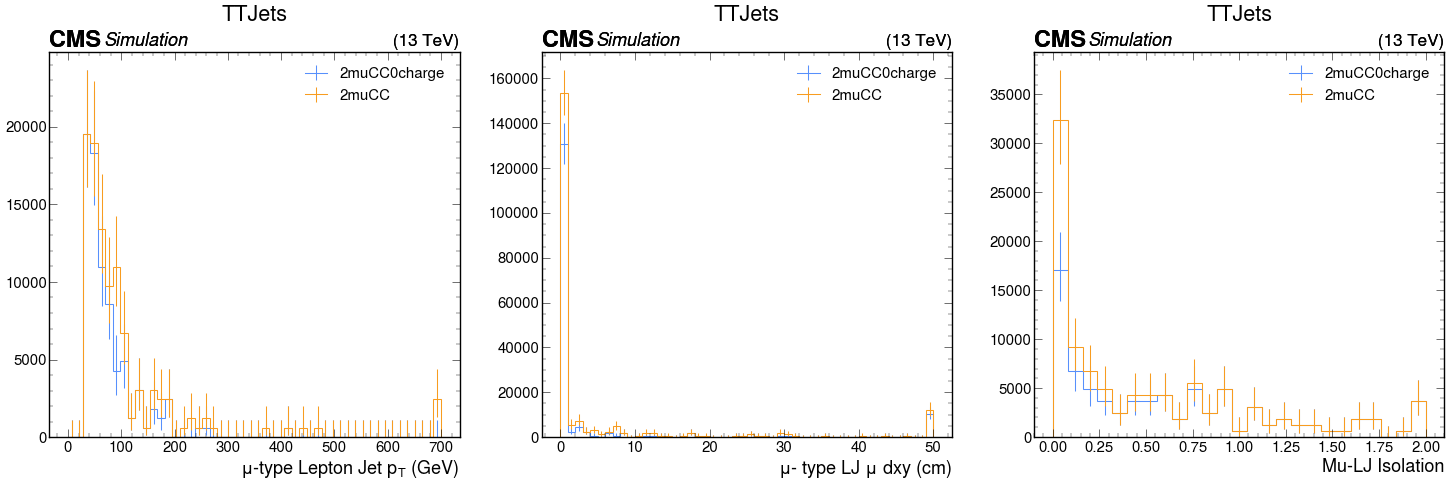

In [16]:
plt.subplots(1, 3, figsize=(36,10))
plt.subplot(1, 3, 1)
channel1 = 1
channel2 = 4
utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(1, 3, 2)
utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channels[channel2], ::2j],label=channels[channel2])
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(1, 3, 3)
utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)
